# **Computer Vision with Deep Learning**

## Visual Recognition

## Lab2b - Transfer Learning for Image Classification

Adapted from `Sasank Chilamkurthy <https://chsasank.github.io>`_

2021 - 23 Veronica Vilaplana - [GPI @ IDEAI](https://imatge.upc.edu/web/) Research group // [ETSETB – UPC.TelecosBCN](https://telecos.upc.edu/ca)

The goal of this assignment is to get hands on experience designing and trainind deep convolutional networks for image classification using PyTorch.
In this assignment you will use PyTorch, which is currently one of the most popular deep learning frameworks. 

<font color=red>The assignment is divided in two parts. You will need to complete **just one part**, depending on your previous background on Deep Learning.</font>

<font color=red>Lab2a is mandatory for students that have not done Deep Learning for Artificial Intelligence (DLAI) in a previous semester.</font>

<font color=red>Lab2b (**this one**) is mandatory for students that have already done Deeep Learning for Artificial Intelligence in a previous semester.
</font>

In the first part of this lab, you will follow a tutorial to learn how to train a network using transfer leanring, and then you will have to complete some tasks to use transfer learning on a different dataset.

Instructions:
1. You can work in teams of two.
2. Add and run your Python code and answer the questions in this same notebook.
3. Upload a zip file with the notebook (after running code cells, including results, confussion matrices, images, etc.) to Atenea.

First, follow this tutorial. 

These two major transfer learning scenarios look as follows:

-  **Finetuning the convnet**: Instead of random initialization, we
   initialize the network with a pretrained network, like the one that is
   trained on imagenet 1000 dataset. Rest of the training looks as
   usual.
-  **ConvNet as fixed feature extractor**: Here, we will freeze the weights
   for all of the network except that of the final fully connected
   layer. This last fully connected layer is replaced with a new one
   with random weights and only this layer is trained.




In [ ]:
# License: BSD
# Author: Sasank Chilamkurthy

from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms

%matplotlib inline
import matplotlib.pyplot as plt
import time
import os
import copy
from sklearn.model_selection import ParameterGrid
import json
import sys
import pandas as pd
import itables

plt.ion()   # interactive mode

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# device = torch.device('cpu')

### Load Data

We will use torchvision and torch.utils.data packages for loading the
data.

The problem we're going to solve is to train a model to classify **ants** and **bees**. 

We have about 120 training images each for ants and bees.
There are 75 validation images for each class. Usually, this is a very small dataset to generalize upon, if trained from scratch. Since we are using transfer learning, we should be able to generalize reasonably well.
This dataset is a very small subset of imagenet.



First, download from ATENEA the file hymenoptera_data.zip. Upload it to the Colab notebook using the menu on the left. Alternatively, you can copy the dataset to your Google Drive and mount gdrive.

In [3]:
#from google.colab import drive
#drive.mount('/content/gdrive')

In [4]:
# !unzip hymenoptera_data.zip 

We will use the ImageFolder Dataset class, which reads images from different folders, where each folder represents a different category. We will use torchvision.transforms to preprocess our data.

In [5]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
       'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),       # Convert the image to a tensor with pixels in the range [0, 1]
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),       # Resize the short side of the image to 150 keeping aspect ratio
        transforms.CenterCrop(224),   # Crop a square in the center of the image
        transforms.ToTensor(),        # Convert the image to a tensor with pixels in the range [0, 1]
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Loading datasets with Pytorch ImageFolder
data_dir = 'hymenoptera_data'

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(class_names)

['ants', 'bees']


###Visualize a few images

Let's visualize a few training images so as to understand the data
augmentations.



In [6]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated




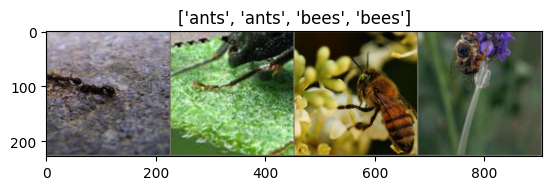

In [7]:
# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

### Training the model

Now, let's write a general function to train a model. Here, we will
illustrate:

-  Scheduling the learning rate
-  Saving the best model

In the following, parameter ``scheduler`` is an LR scheduler object from
``torch.optim.lr_scheduler``.



In [8]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                scheduler.step()
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

### Visualizing the model predictions

Generic function to display predictions for a few images




In [9]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title('predicted: {}'.format(class_names[preds[j]]))
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

# Option 1: Finetuning the convnet

Load a pretrained model and reset final fully connected layer.




In [10]:
model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

/home/enric/Master/cvdl/cvdl-labs/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/enric/Master/cvdl/cvdl-labs/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
def print_model(model):
    print(model)
    for name, param in model.named_parameters():
        print(f'{name:20} {param.numel()} {list(param.shape)} {param.requires_grad}')
    print(f'TOTAL                {sum(p.numel() for p in model.parameters())}')

In [12]:
print_model(model_ft)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Train and evaluate

It should take around 15-25 min on CPU. On GPU though, it takes less than a
minute.




In [13]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------


/home/enric/Master/cvdl/cvdl-labs/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:189: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
/tmp/ipykernel_126584/1284057464.py:43: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/aten/src/ATen/native/Scalar.cpp:22.)
  running_loss += loss.item() * inputs.size(0)


train Loss: 0.4668 Acc: 0.7295
val Loss: 0.2992 Acc: 0.8889

Epoch 1/24
----------
train Loss: 0.4885 Acc: 0.8279
val Loss: 0.2807 Acc: 0.9216

Epoch 2/24
----------
train Loss: 0.6264 Acc: 0.7910
val Loss: 0.2437 Acc: 0.9216

Epoch 3/24
----------
train Loss: 0.6861 Acc: 0.7336
val Loss: 0.2721 Acc: 0.9020

Epoch 4/24
----------
train Loss: 0.4365 Acc: 0.8238
val Loss: 0.2425 Acc: 0.9216

Epoch 5/24
----------
train Loss: 0.5944 Acc: 0.7910
val Loss: 0.3934 Acc: 0.8366

Epoch 6/24
----------
train Loss: 0.3693 Acc: 0.8525
val Loss: 0.2579 Acc: 0.8954

Epoch 7/24
----------
train Loss: 0.4579 Acc: 0.7910
val Loss: 0.2050 Acc: 0.9281

Epoch 8/24
----------
train Loss: 0.3002 Acc: 0.8689
val Loss: 0.2172 Acc: 0.9281

Epoch 9/24
----------
train Loss: 0.3231 Acc: 0.8648
val Loss: 0.2256 Acc: 0.9085

Epoch 10/24
----------
train Loss: 0.3781 Acc: 0.8320
val Loss: 0.2249 Acc: 0.9281

Epoch 11/24
----------
train Loss: 0.2893 Acc: 0.8689
val Loss: 0.1983 Acc: 0.9281

Epoch 12/24
----------
t

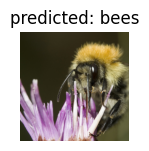

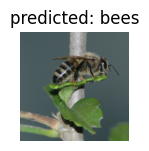

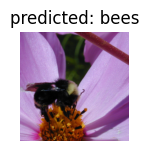

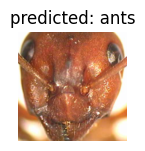

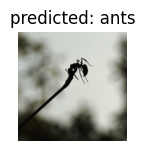

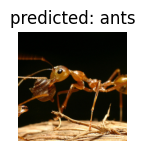

In [14]:
visualize_model(model_ft)

# Option 2: ConvNet as fixed feature extractor

Here, we need to freeze all the network except the final layer. We need
to set ``requires_grad == False`` to freeze the parameters so that the
gradients are not computed in ``backward()``.

You can read more about this in the documentation
`here <http://pytorch.org/docs/notes/autograd.html#excluding-subgraphs-from-backward>`__.




In [15]:
model_conv = torchvision.models.resnet18(pretrained=True)
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opoosed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

### Train and evaluate

On CPU this will take about half the time compared to previous scenario.
This is expected as gradients don't need to be computed for most of the
network. However, forward does need to be computed.




In [16]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.6168 Acc: 0.6721
val Loss: 0.2391 Acc: 0.9412

Epoch 1/24
----------
train Loss: 0.5269 Acc: 0.7336
val Loss: 0.2197 Acc: 0.9281

Epoch 2/24
----------
train Loss: 0.4204 Acc: 0.8320
val Loss: 0.2021 Acc: 0.9346

Epoch 3/24
----------
train Loss: 0.3721 Acc: 0.8443
val Loss: 0.3803 Acc: 0.8562

Epoch 4/24
----------
train Loss: 0.5482 Acc: 0.7992
val Loss: 0.1973 Acc: 0.9150

Epoch 5/24
----------
train Loss: 0.4532 Acc: 0.8402
val Loss: 0.2276 Acc: 0.9412

Epoch 6/24
----------
train Loss: 0.3248 Acc: 0.8443
val Loss: 0.1997 Acc: 0.9412

Epoch 7/24
----------
train Loss: 0.3796 Acc: 0.8320
val Loss: 0.2150 Acc: 0.9346

Epoch 8/24
----------
train Loss: 0.3802 Acc: 0.8361
val Loss: 0.2045 Acc: 0.9477

Epoch 9/24
----------
train Loss: 0.3612 Acc: 0.8484
val Loss: 0.1949 Acc: 0.9412

Epoch 10/24
----------
train Loss: 0.3448 Acc: 0.8607
val Loss: 0.1976 Acc: 0.9412

Epoch 11/24
----------
train Loss: 0.3457 Acc: 0.8525
val Loss: 0.1928 Acc: 0.9346

Ep

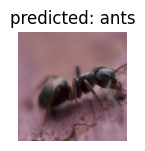

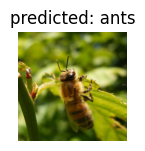

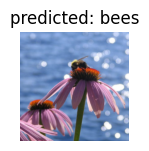

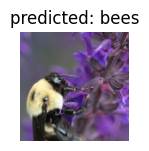

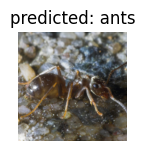

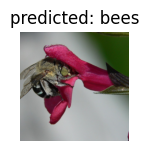

In [17]:
visualize_model(model_conv)

plt.ioff()
plt.show()

# Tasks

---

Now, you will use a model pre-trained on ImageNet for classifying the Caltech-UCSD Birds dataset (200 categories of birds, 3000 images in train and 3033 images in test). 

0. Load and unzip the dataset (file CaltechBirds.zip)

1. Split the 'train' set into 'train' and 'validation' splits. In the following experiments use the train and validation splits to train and select the best model and then evaluate on the test split (you will need to modify the previous code).

2. Use the ResNet18 model pretrained on ImageNet with the parameters used in the previous example. Use the two approaches (fixed feature extractor or fine-tuning the model)

3. Vary hyperparameters to improve the performance

4. Compute and show additional metrics

5. Repeat using a different pre-trained model available in Pytorch
https://pytorch.org/vision/stable/models.html (DenseNet, ResNExt etc. Do not use a deeper ResNet)


### 0. Load and unzip the data

In [18]:
#!unzip CaltechBirds.zip

###  1. Split the 'train' set into 'train' and 'validation' splits. In the following experiments use the train and validation splits to train and select the best model and then evaluate on the test split (you will need to modify the previous code).

In [19]:
from sklearn.model_selection import train_test_split

# Data augmentation and normalization for training
# Just normalization for validation
# Loading datasets with Pytorch ImageFolder
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),       # Convert the image to a tensor with pixels in the range [0, 1]
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
train_dataset = datasets.ImageFolder(
                os.path.join('CaltechBirds', 'train'),
                train_transforms
            )

targetIdxs = train_dataset.targets
x_train, x_val, y_train, y_val = train_test_split(train_dataset, targetIdxs, test_size=0.15, random_state=2)

train_dataloaders = torch.utils.data.DataLoader(x_train, batch_size=16, shuffle=True, num_workers=4)
val_dataloaders = torch.utils.data.DataLoader(x_val, batch_size=16, shuffle=True, num_workers=4)
print("Train length", len(x_train))
print("Val length", len(x_val))

class_names = train_dataset.classes


Train length 2550
Val length 450


In [20]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(train_dataloaders):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title('predicted: {}'.format(class_names[preds[j]]))
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

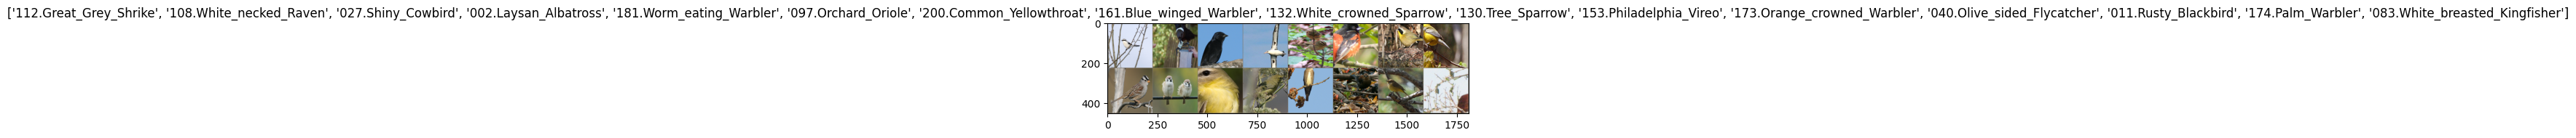

In [21]:
# Get a batch of training data
inputs, classes = next(iter(train_dataloaders))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [22]:
def train_epoch(model, criterion, optimizer, dataloader, size, device):
    model.train()  # Set model to training mode
    
    running_loss = 0.0
    running_corrects = 0
    
    # Iterate over training data
    for inputs, label_indices in dataloader:
        inputs = inputs.to(device)
        label_indices = label_indices.to(device)
        
        # zero the parameter gradients
        optimizer.zero_grad()
        
        # forward pass
        with torch.set_grad_enabled(True):
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, label_indices)
            
            # backward + optimize
            loss.backward()
            optimizer.step()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # statistics
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == label_indices.data)
    
    epoch_loss = running_loss / size
    epoch_acc = running_corrects.double() / size
    
    return epoch_loss, epoch_acc

In [23]:
def test_model(model, criterion, scheduler, dataloader, size, device):
    model.eval()  # Set model to evaluate mode
    running_loss = 0.0
    running_corrects = 0

    # Iterate over data
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # forward
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            # statistics
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
    epoch_loss = running_loss / size
    epoch_acc = running_corrects.double() / size

    scheduler.step(epoch_loss)
    
    return epoch_loss, epoch_acc

In [24]:
def run_training(model, criterion, optimizer, scheduler, dataloaders, dataset_size, device, num_epochs=25, name=None):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    best_train_acc = 0.0
    best_epoch = 0
    
    best_val_loss = 0
    best_train_loss = 0
    patience = 0
    training_losses = []
    validation_losses = []

    # for epoch in range(num_epochs):
    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}/{num_epochs}')
        print('-' * 10)
        
        train_loss, train_acc = train_epoch(model, criterion, optimizer, dataloaders['train'], dataset_size['train'], device)
        training_losses.append(train_loss)
        print('Train Loss: {:.4f} Acc: {:.4f}'.format(train_loss, train_acc))
        
        val_loss, val_acc = test_model(model, criterion, scheduler, dataloaders['val'], dataset_size['val'], device)
        validation_losses.append(val_loss)
        print('Val Loss: {:.4f} Acc: {:.4f}'.format(val_loss, val_acc))
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc.item()
            best_train_acc = train_acc.item()
            best_epoch = epoch
            best_val_loss = val_loss
            best_train_loss = train_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            patience = 0
        else:
            patience += 1
            if patience > 5:
                print("Early stopping")
                break
    
    if name is not None:
        fold = './results/' + name
        os.makedirs(fold, exist_ok=True)

        # plot training and validation loss
        plt.figure(figsize=(10, 5))
        plt.plot(training_losses, label='Training Loss')
        plt.plot(validation_losses, label='Validation Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.savefig(fold + '/loss.png')
        plt.close()
        
    
    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_val_acc))
    
    # load best model weights
    model_to_return = copy.deepcopy(model)
    model_to_return.load_state_dict(best_model_wts)
    return model_to_return, { 'best_val_acc': best_val_acc, 'best_train_acc': best_train_acc, 'best_epoch': best_epoch, 'best_val_loss': best_val_loss, 'best_train_loss': best_train_loss }, time_elapsed

### 2. Use the ResNet18 model pretrained on ImageNet with the parameters used in the previous example. Use the two approaches (fixed feature extractor or fine-tuning the model)

#### 2.1 Fixed feature extractor

In [25]:
model_feat_extractor = torchvision.models.resnet18(pretrained=True)
print_model(model_feat_extractor)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [26]:
for param in model_feat_extractor.parameters():
    param.requires_grad = False

classifier_feat_extractor =  nn.Linear(model_feat_extractor.fc.in_features, len(train_dataset.classes))
# Parameters of newly constructed modules have requires_grad=True by default
model_feat_extractor.fc = classifier_feat_extractor

model_feat_extractor = model_feat_extractor.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opoosed to before.
optimizer_feat_extractor = optim.SGD(model_feat_extractor.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
scheduler_feat_extractor = lr_scheduler.StepLR(optimizer_feat_extractor, step_size=7, gamma=0.1)

In [27]:
model_feature_extractor, _, _= run_training(
    model_feat_extractor,
    criterion,
    optimizer_feat_extractor,
    scheduler_feat_extractor,
    {'train': train_dataloaders, 'val': val_dataloaders},
    {'train': len(x_train), 'val': len(x_val)},
    device,
    num_epochs=50
)

Epoch 1/50
----------
Train Loss: 5.3516 Acc: 0.0055
Val Loss: 5.1529 Acc: 0.0200
Epoch 2/50
----------


/home/enric/Master/cvdl/cvdl-labs/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:205: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Train Loss: 4.9473 Acc: 0.0518
Val Loss: 4.9245 Acc: 0.0511
Epoch 3/50
----------
Train Loss: 4.5957 Acc: 0.1318
Val Loss: 4.6542 Acc: 0.0911
Epoch 4/50
----------
Train Loss: 4.2832 Acc: 0.2071
Val Loss: 4.4482 Acc: 0.0933
Epoch 5/50
----------
Train Loss: 4.0007 Acc: 0.2863
Val Loss: 4.2369 Acc: 0.1422
Epoch 6/50
----------
Train Loss: 3.7504 Acc: 0.3682
Val Loss: 4.0959 Acc: 0.1467
Epoch 7/50
----------
Train Loss: 3.5150 Acc: 0.4318
Val Loss: 3.9537 Acc: 0.1867
Epoch 8/50
----------
Train Loss: 3.3060 Acc: 0.4808
Val Loss: 3.8199 Acc: 0.2156
Epoch 9/50
----------
Train Loss: 3.1023 Acc: 0.5282
Val Loss: 3.6932 Acc: 0.2378
Epoch 10/50
----------
Train Loss: 2.9304 Acc: 0.5722
Val Loss: 3.5897 Acc: 0.2578
Epoch 11/50
----------
Train Loss: 2.7626 Acc: 0.6071
Val Loss: 3.5065 Acc: 0.2689
Epoch 12/50
----------
Train Loss: 2.6325 Acc: 0.6396
Val Loss: 3.4322 Acc: 0.2689
Epoch 13/50
----------
Train Loss: 2.4903 Acc: 0.6553
Val Loss: 3.3502 Acc: 0.2844
Epoch 14/50
----------
Train Loss:

#### 2.2 Fine-tuning

In [28]:
model_fine_tuning = torchvision.models.resnet18(pretrained=True)

In [29]:
for param in model_fine_tuning.parameters():
    param.requires_grad = False

for layer in model_fine_tuning.layer4:
    for param in layer.parameters():
        param.requires_grad = True


for param in model_fine_tuning.avgpool.parameters():
    param.requires_grad = True

# We reuse the classifier from the feature extractor as it has some good weigth initialization
model_fine_tuning.fc = classifier_feat_extractor

for param in model_fine_tuning.fc.parameters():
    param.requires_grad = True

print_model(model_fine_tuning)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [30]:
print(torch.equal(model_fine_tuning.fc.weight, model_feat_extractor.fc.weight))


True


In [31]:
model_fine_tuning = model_fine_tuning.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_fine_tuning = optim.SGD([p for p in model_fine_tuning.parameters() if p.requires_grad], lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
scheduler_fine_tuning = lr_scheduler.StepLR(optimizer_fine_tuning, step_size=7, gamma=0.1)

In [32]:
model_fine_tuning, _, _ = run_training(
    model_fine_tuning,
    criterion,
    optimizer_fine_tuning,
    scheduler_fine_tuning,
    {'train': train_dataloaders, 'val': val_dataloaders},
    {'train': len(x_train), 'val': len(x_val)},
    device,
    num_epochs=50
)

Epoch 1/50
----------
Train Loss: 1.1490 Acc: 0.8659
Val Loss: 2.5903 Acc: 0.3844
Epoch 2/50
----------
Train Loss: 0.8055 Acc: 0.9259
Val Loss: 2.5292 Acc: 0.3933
Epoch 3/50
----------
Train Loss: 0.5862 Acc: 0.9671
Val Loss: 2.5284 Acc: 0.3956
Epoch 4/50
----------
Train Loss: 0.4591 Acc: 0.9796
Val Loss: 2.5315 Acc: 0.4000
Epoch 5/50
----------
Train Loss: 0.3606 Acc: 0.9918
Val Loss: 2.4987 Acc: 0.4022
Epoch 6/50
----------
Train Loss: 0.2873 Acc: 0.9925
Val Loss: 2.5246 Acc: 0.3978
Epoch 7/50
----------
Train Loss: 0.2314 Acc: 0.9957
Val Loss: 2.5224 Acc: 0.4044
Epoch 8/50
----------
Train Loss: 0.1945 Acc: 0.9957
Val Loss: 2.5173 Acc: 0.4089
Epoch 9/50
----------
Train Loss: 0.1755 Acc: 0.9973
Val Loss: 2.5307 Acc: 0.3978
Epoch 10/50
----------
Train Loss: 0.1522 Acc: 0.9984
Val Loss: 2.5115 Acc: 0.4222
Epoch 11/50
----------
Train Loss: 0.1317 Acc: 0.9988
Val Loss: 2.4729 Acc: 0.4133
Epoch 12/50
----------
Train Loss: 0.1173 Acc: 0.9988
Val Loss: 2.5150 Acc: 0.4044
Epoch 13/50
-

### 3. Vary hyperparameters to improve the performance
### 4. Compute and show additional metrics

#### 3.1 Feature extractor

In [33]:
from io import StringIO

output_buffer = StringIO()
original_stdout = sys.stdout
sys.stdout = tee_stdout = type('TeeStdout', (), {
    'write': lambda self, x: (output_buffer.write(x), original_stdout.write(x)),
    'flush': lambda self: (output_buffer.flush(), original_stdout.flush())
})()

timestamp = int(time.time())
try: 

    param_grid = {
        'learning_rate': [0.01, 0.001,0.0001, 0.1],
        'weight_decay': [0, 0.0001,  0.001],                 
        'dropout_rate': [0, 0.2, 0.5],
    }

    tried_combinations_file = f"./results/tried_f_e_combinations.json"
    tried_combinations = []

    # Load previously tried combinations if resuming
    if os.path.exists(tried_combinations_file):
        with open(tried_combinations_file, 'r') as f:
            tried_combinations = json.load(f)



    grid = list(ParameterGrid(param_grid))
    print(f"Total Feature extractor combinations: {len(grid)}")


    table_data = []
    best_f_e_grid_model = None
    best_f_e_grid_metrics = { 'best_val_acc': 0, 'best_train_acc': 0, 'best_epoch': 0, 'best_val_loss': 0, 'best_train_loss': 0 }
    best_f_e_params = None
    best_f_e_classifier = None
    criterion = nn.CrossEntropyLoss()
    def param_to_str(params):
        return json.dumps(params, sort_keys=True)

    for i, params in enumerate(grid):
        folder_name = f"f-e-{params['dropout_rate']}-{params['learning_rate']}-{params['weight_decay']}"
        model_f_e_grid = torchvision.models.resnet18(pretrained=True)
        for param in model_f_e_grid.parameters():
            param.requires_grad = False


        params_str = param_to_str(params)
        if params_str in tried_combinations:
            print(f"Skipping already tried combination {i+1}/{len(grid)}: {params}")
            continue
        print(f"Trying combination {i+1}/{len(grid)}: {params}")
        try:
            classifier = nn.Sequential(
                    nn.Dropout(params['dropout_rate']),
                    nn.Linear(model_f_e_grid.fc.in_features, len(train_dataset.classes))
                )
            model_f_e_grid.fc = classifier
            model_f_e_grid = model_f_e_grid.to(device)

            optimizer_f_e_grid = optim.Adam(
                model_f_e_grid.fc.parameters(),
                lr=params['learning_rate'],
                weight_decay=params['weight_decay'],
            )
            scheduler_f_e_grid = lr_scheduler.ReduceLROnPlateau(optimizer_f_e_grid)
            best_model_f_e_grid, metrics, time_elapsed = run_training(
                model_f_e_grid,
                criterion,
                optimizer_f_e_grid,
                scheduler_f_e_grid,
                {'train': train_dataloaders, 'val': val_dataloaders},
                {'train': len(x_train), 'val': len(x_val)},
                device,
                num_epochs=50,
                name=folder_name
            )

            table_data.append({
                'learning_rate': params['learning_rate'],
                'weight_decay': params['weight_decay'],
                'dropout_rate': params['dropout_rate'],
                'val_accuracy': metrics['best_val_acc'],
                'train_accuracy': metrics['best_train_acc'],
                'val_loss': metrics['best_val_loss'],
                'train_loss': metrics['best_train_loss'],
                'epoch': metrics['best_epoch'],
                'time_elapsed': time_elapsed,
            })

            if metrics['best_val_acc'] > best_f_e_grid_metrics['best_val_acc']:
                best_f_e_params = params
                best_f_e_grid_model = best_model_f_e_grid
                best_f_e_grid_metrics = metrics
                best_f_e_classifier = classifier
            
            tried_combinations.append(params_str)
            with open(tried_combinations_file, 'w') as f:
                json.dump(tried_combinations, f)

        except Exception as e:
            print(f"Error with params {params}", str(e))    
finally:
    # Restore original stdout
    sys.stdout = original_stdout
    # Write captured output to file
    with open(f"./results/output-f-e-{timestamp}.txt", 'w') as file:
        file.write(output_buffer.getvalue())


Total Feature extractor combinations: 36
Trying combination 1/36: {'dropout_rate': 0, 'learning_rate': 0.01, 'weight_decay': 0}
Epoch 1/50
----------
Train Loss: 8.2117 Acc: 0.0839
Val Loss: 6.3264 Acc: 0.1467
Epoch 2/50
----------
Train Loss: 3.7708 Acc: 0.3710
Val Loss: 7.1561 Acc: 0.2067
Epoch 3/50
----------
Train Loss: 2.8826 Acc: 0.4973
Val Loss: 6.2163 Acc: 0.2200
Epoch 4/50
----------
Train Loss: 2.0424 Acc: 0.5976
Val Loss: 6.9456 Acc: 0.2467
Epoch 5/50
----------
Train Loss: 1.8596 Acc: 0.6447
Val Loss: 7.8883 Acc: 0.2578
Epoch 6/50
----------
Train Loss: 1.4808 Acc: 0.7165
Val Loss: 8.0285 Acc: 0.2289
Epoch 7/50
----------
Train Loss: 1.2207 Acc: 0.7620
Val Loss: 8.9416 Acc: 0.2333
Epoch 8/50
----------
Train Loss: 1.3830 Acc: 0.7518
Val Loss: 8.1199 Acc: 0.2622
Epoch 9/50
----------
Train Loss: 1.1494 Acc: 0.8004
Val Loss: 8.5205 Acc: 0.2533
Epoch 10/50
----------
Train Loss: 0.9308 Acc: 0.8149
Val Loss: 9.2142 Acc: 0.2600
Epoch 11/50
----------
Train Loss: 1.3131 Acc: 0.78

Grid search Feature extractor completed. Best metrics: {'best_val_acc': 0.4022222222222222, 'best_train_acc': 0.9596078431372549, 'best_epoch': 14, 'best_val_loss': 2.7968085426754423, 'best_train_loss': 0.3916762491768482}
Best parameters: {'dropout_rate': 0, 'learning_rate': 0.001, 'weight_decay': 0}


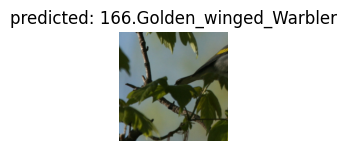

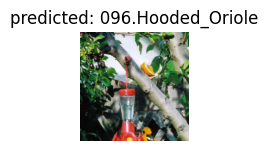

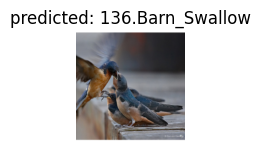

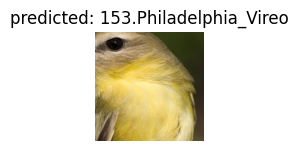

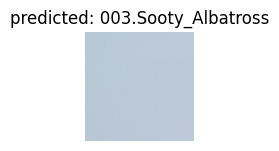

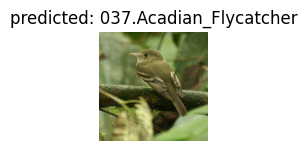

In [34]:
print(f"Grid search Feature extractor completed. Best metrics: {best_f_e_grid_metrics}")
print(f"Best parameters: {best_f_e_params}")

torch.save(best_f_e_grid_model.state_dict(), f"./results/best_model_f_e_{timestamp}.pth")

visualize_model(best_f_e_grid_model, num_images=6)

df = pd.DataFrame(table_data)
itables.show(df, 
             lengthMenu=[5, 10, 20], 
             scrollX=True, 
             classes="display compact"
            )
df.to_csv(f"./results/grid_search_results_feature_extractor_{timestamp}.csv", index=False)

#### 3.2 Fine-tunning

In [35]:
import json
import sys
import pandas as pd

output_buffer = StringIO()
original_stdout = sys.stdout
sys.stdout = tee_stdout = type('TeeStdout', (), {
    'write': lambda self, x: (output_buffer.write(x), original_stdout.write(x)),
    'flush': lambda self: (output_buffer.flush(), original_stdout.flush())
})()

timestamp = int(time.time())
try:
    param_grid = {
        'learning_rate': [0.01, 0.001,0.0001, 0.1],
        'weight_decay': [0, 0.0001,  0.001],                 
    }
    
    tried_combinations_file = f"./results/tried_f_t_combinations.json"
    tried_combinations = []

    if os.path.exists(tried_combinations_file):
        with open(tried_combinations_file, 'r') as f:
            tried_combinations = json.load(f)


    grid = list(ParameterGrid(param_grid))
    print(f"Total Fine tunning combinations: {len(grid)}")


    table_data = []
    best_f_t_grid_model = None
    best_f_t_grid_metrics = { 'best_val_acc': 0, 'best_train_acc': 0, 'best_epoch': 0, 'best_val_loss': 0, 'best_train_loss': 0 }
    best_f_t_params = None
    criterion = nn.CrossEntropyLoss()
    def param_to_str(params):
        return json.dumps(params, sort_keys=True)

    for i, params in enumerate(grid):
        folder_name = f"f-t-{params['learning_rate']}-{params['weight_decay']}"
        model_f_t_grid = torchvision.models.resnet18(pretrained=True)
        for param in model_f_t_grid.parameters():
            param.requires_grad = False

        for layer in model_f_t_grid.layer4:
            for param in layer.parameters():
                param.requires_grad = True


        for param in model_f_t_grid.avgpool.parameters():
            param.requires_grad = True

        # We reuse the classifier from the feature extractor as it has some good weigth initialization
        model_f_t_grid.fc = best_f_e_classifier

        for param in model_f_t_grid.fc.parameters():
            param.requires_grad = True

        model_f_t_grid = model_f_t_grid.to(device)
        params_str = param_to_str(params)
        if params_str in tried_combinations:
            print(f"Skipping already tried combination {i+1}/{len(grid)}: {params}")
            continue
        print(f"Trying combination {i+1}/{len(grid)}: {params}")
        try:

            optimizer_f_e_grid = optim.Adam(
                model_f_t_grid.fc.parameters(),
                lr=params['learning_rate'],
                weight_decay=params['weight_decay'],
            )
            scheduler_f_e_grid = lr_scheduler.ReduceLROnPlateau(optimizer_f_e_grid)
            best_model_f_t_grid, metrics, time_elapsed = run_training(
                model_f_t_grid,
                criterion,
                optimizer_f_e_grid,
                scheduler_f_e_grid,
                {'train': train_dataloaders, 'val': val_dataloaders},
                {'train': len(x_train), 'val': len(x_val)},
                device,
                num_epochs=50,
                name=folder_name
            )

            table_data.append({
                'learning_rate': params['learning_rate'],
                'weight_decay': params['weight_decay'],
                'dropout_rate': best_model_f_t_grid.fc[0].p,
                'val_accuracy': metrics['best_val_acc'],
                'train_accuracy': metrics['best_train_acc'],
                'val_loss': metrics['best_val_loss'],
                'train_loss': metrics['best_train_loss'],
                'epoch': metrics['best_epoch'],
                'time_elapsed': time_elapsed,
            })

            if metrics['best_val_acc'] > best_f_t_grid_metrics['best_val_acc']:
                best_f_t_params = params
                best_f_t_grid_model = best_model_f_t_grid
                best_f_t_grid_metrics = metrics
            
            tried_combinations.append(params_str)
            with open(tried_combinations_file, 'w') as f:
                json.dump(tried_combinations, f)

        except Exception as e:
            print(f"Error with params {params}", str(e))
finally:
    # Restore original stdout
    sys.stdout = original_stdout
    # Write captured output to file
    with open(f"./results/output-f-t-{timestamp}.txt", 'w') as file:
        file.write(output_buffer.getvalue())

Total Fine tunning combinations: 12
Trying combination 1/12: {'learning_rate': 0.01, 'weight_decay': 0}
Epoch 1/50
----------
Train Loss: 3.7185 Acc: 0.4294
Val Loss: 6.5770 Acc: 0.2467
Epoch 2/50
----------
Train Loss: 2.2726 Acc: 0.5969
Val Loss: 7.9240 Acc: 0.2222
Epoch 3/50
----------
Train Loss: 2.0272 Acc: 0.6416
Val Loss: 7.4599 Acc: 0.2711
Epoch 4/50
----------
Train Loss: 1.6190 Acc: 0.7114
Val Loss: 6.7372 Acc: 0.2844
Epoch 5/50
----------
Train Loss: 1.3289 Acc: 0.7416
Val Loss: 8.4033 Acc: 0.2689
Epoch 6/50
----------
Train Loss: 1.2318 Acc: 0.7647
Val Loss: 8.5223 Acc: 0.2889
Epoch 7/50
----------
Train Loss: 1.1811 Acc: 0.7922
Val Loss: 9.0616 Acc: 0.3111
Epoch 8/50
----------
Train Loss: 1.2713 Acc: 0.7859
Val Loss: 9.1813 Acc: 0.2533
Epoch 9/50
----------
Train Loss: 1.1842 Acc: 0.8043
Val Loss: 8.9098 Acc: 0.3044
Epoch 10/50
----------
Train Loss: 1.0816 Acc: 0.8106
Val Loss: 9.4182 Acc: 0.2800
Epoch 11/50
----------
Train Loss: 0.7398 Acc: 0.8545
Val Loss: 10.1337 Acc

Grid search fine tunning completed. Best metrics: {'best_val_acc': 0.3844444444444444, 'best_train_acc': 0.9984313725490196, 'best_epoch': 0, 'best_val_loss': 3.019103800455729, 'best_train_loss': 0.08234044626647351}
Best parameters: {'learning_rate': 0.0001, 'weight_decay': 0.0001}


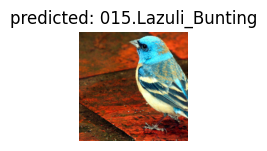

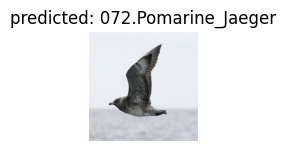

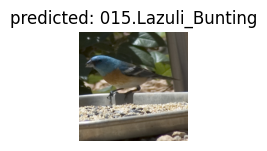

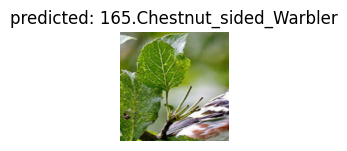

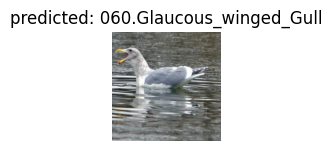

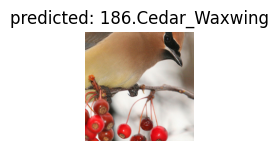

In [36]:
print(f"Grid search fine tunning completed. Best metrics: {best_f_t_grid_metrics}")
print(f"Best parameters: {best_f_t_params}")

torch.save(best_f_t_grid_model.state_dict(), f"./results/best_model_f_t_{timestamp}.pth")
visualize_model(best_f_t_grid_model, num_images=6)

df = pd.DataFrame(table_data)
df.to_csv(f"./results/grid_search_results_fine_tuning_{timestamp}.csv", index=False)
itables.show(df, 
             lengthMenu=[5, 10, 20], 
             scrollX=True, 
             classes="display compact"
            )

### 5. Repeat using a different pre-trained model available in Pytorch

#### 5.1 Fixed feature extractor

In [37]:
model_new_feat_extractor = torchvision.models.densenet121(pretrained=True)
print_model(model_new_feat_extractor)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

/home/enric/Master/cvdl/cvdl-labs/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [38]:
for param in model_new_feat_extractor.parameters():
    param.requires_grad = False

classifier_new_feat_extractor =  nn.Linear(model_new_feat_extractor.classifier.in_features, len(train_dataset.classes))
# Parameters of newly constructed modules have requires_grad=True by default
model_new_feat_extractor.classifier = classifier_new_feat_extractor

model_new_feat_extractor = model_new_feat_extractor.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opoosed to before.
optimizer_new_feat_extractor = optim.SGD(model_new_feat_extractor.classifier.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
scheduler_new_feat_extractor = lr_scheduler.StepLR(optimizer_feat_extractor, step_size=7, gamma=0.1)

In [39]:
model_new_feature_extractor, _, _= run_training(
    model_new_feat_extractor,
    criterion,
    optimizer_new_feat_extractor,
    scheduler_new_feat_extractor,
    {'train': train_dataloaders, 'val': val_dataloaders},
    {'train': len(x_train), 'val': len(x_val)},
    device,
    num_epochs=50
)

Epoch 1/50
----------
Train Loss: 5.3116 Acc: 0.0106
Val Loss: 5.1602 Acc: 0.0267
Epoch 2/50
----------
Train Loss: 4.9214 Acc: 0.0725
Val Loss: 4.8792 Acc: 0.1111
Epoch 3/50
----------
Train Loss: 4.5622 Acc: 0.1616
Val Loss: 4.6394 Acc: 0.1244
Epoch 4/50
----------
Train Loss: 4.2292 Acc: 0.2643
Val Loss: 4.4127 Acc: 0.1844
Epoch 5/50
----------
Train Loss: 3.9369 Acc: 0.3651
Val Loss: 4.2243 Acc: 0.1956
Epoch 6/50
----------
Train Loss: 3.6692 Acc: 0.4455
Val Loss: 4.0601 Acc: 0.2289
Epoch 7/50
----------
Train Loss: 3.4115 Acc: 0.5255
Val Loss: 3.8802 Acc: 0.2756
Epoch 8/50
----------
Train Loss: 3.1766 Acc: 0.5804
Val Loss: 3.7389 Acc: 0.2889
Epoch 9/50
----------
Train Loss: 2.9754 Acc: 0.6357
Val Loss: 3.6224 Acc: 0.3044
Epoch 10/50
----------
Train Loss: 2.7854 Acc: 0.6608
Val Loss: 3.4957 Acc: 0.3111
Epoch 11/50
----------
Train Loss: 2.6071 Acc: 0.6996
Val Loss: 3.3876 Acc: 0.3533
Epoch 12/50
----------
Train Loss: 2.4427 Acc: 0.7290
Val Loss: 3.2968 Acc: 0.3600
Epoch 13/50
-

In [40]:
from io import StringIO

output_buffer = StringIO()
original_stdout = sys.stdout
sys.stdout = tee_stdout = type('TeeStdout', (), {
    'write': lambda self, x: (output_buffer.write(x), original_stdout.write(x)),
    'flush': lambda self: (output_buffer.flush(), original_stdout.flush())
})()

timestamp = int(time.time())
try: 

    param_grid = {
        'learning_rate': [0.01, 0.001,0.0001, 0.1],
        'weight_decay': [0, 0.0001,  0.001],                 
        'dropout_rate': [0, 0.2, 0.5],
    }

    tried_combinations_file = f"./results/tried_n_f_e_combinations.json"
    tried_combinations = []

    # Load previously tried combinations if resuming
    if os.path.exists(tried_combinations_file):
        with open(tried_combinations_file, 'r') as f:
            tried_combinations = json.load(f)



    grid = list(ParameterGrid(param_grid))
    print(f"Total Feature extractor combinations: {len(grid)}")


    table_data = []
    best_n_f_e_grid_model = None
    best_n_f_e_grid_metrics = { 'best_val_acc': 0, 'best_train_acc': 0, 'best_epoch': 0, 'best_val_loss': 0, 'best_train_loss': 0 }
    best_n_f_e_params = None
    best_n_f_e_classifier = None
    criterion = nn.CrossEntropyLoss()
    def param_to_str(params):
        return json.dumps(params, sort_keys=True)

    for i, params in enumerate(grid):
        folder_name = f"f-e-{params['dropout_rate']}-{params['learning_rate']}-{params['weight_decay']}"
        model_n_f_e_grid = torchvision.models.densenet121(pretrained=True)
        for param in model_n_f_e_grid.parameters():
            param.requires_grad = False


        params_str = param_to_str(params)
        if params_str in tried_combinations:
            print(f"Skipping already tried combination {i+1}/{len(grid)}: {params}")
            continue
        print(f"Trying combination {i+1}/{len(grid)}: {params}")
        try:
            classifier = nn.Sequential(
                    nn.Dropout(params['dropout_rate']),
                    nn.Linear(model_n_f_e_grid.classifier.in_features, len(train_dataset.classes))
                )
            model_n_f_e_grid.classifier = classifier
            model_n_f_e_grid = model_n_f_e_grid.to(device)

            optimizer_n_f_e_grid = optim.Adam(
                model_n_f_e_grid.classifier.parameters(),
                lr=params['learning_rate'],
                weight_decay=params['weight_decay'],
            )
            scheduler_n_f_e_grid = lr_scheduler.ReduceLROnPlateau(optimizer_n_f_e_grid)
            best_model_n_f_e_grid, metrics, time_elapsed = run_training(
                model_n_f_e_grid,
                criterion,
                optimizer_n_f_e_grid,
                scheduler_n_f_e_grid,
                {'train': train_dataloaders, 'val': val_dataloaders},
                {'train': len(x_train), 'val': len(x_val)},
                device,
                num_epochs=50,
                name=folder_name
            )

            table_data.append({
                'learning_rate': params['learning_rate'],
                'weight_decay': params['weight_decay'],
                'dropout_rate': params['dropout_rate'],
                'val_accuracy': metrics['best_val_acc'],
                'train_accuracy': metrics['best_train_acc'],
                'val_loss': metrics['best_val_loss'],
                'train_loss': metrics['best_train_loss'],
                'epoch': metrics['best_epoch'],
                'time_elapsed': time_elapsed,
            })

            if metrics['best_val_acc'] > best_n_f_e_grid_metrics['best_val_acc']:
                best_n_f_e_params = params
                best_n_f_e_grid_model = best_model_n_f_e_grid
                best_n_f_e_grid_metrics = metrics
                best_n_f_e_classifier = classifier
            
            tried_combinations.append(params_str)
            with open(tried_combinations_file, 'w') as f:
                json.dump(tried_combinations, f)

        except Exception as e:
            print(f"Error with params {params}", str(e))


finally:
    # Restore original stdout
    sys.stdout = original_stdout
    # Write captured output to file
    with open(f"./results/output-n-f-e-{timestamp}.txt", 'w') as file:
        file.write(output_buffer.getvalue())


Total Feature extractor combinations: 36
Trying combination 1/36: {'dropout_rate': 0, 'learning_rate': 0.01, 'weight_decay': 0}
Epoch 1/50
----------
Train Loss: 7.8977 Acc: 0.0882
Val Loss: 4.7916 Acc: 0.2444
Epoch 2/50
----------
Train Loss: 3.1325 Acc: 0.4463
Val Loss: 5.5568 Acc: 0.2778
Epoch 3/50
----------
Train Loss: 2.1172 Acc: 0.5929
Val Loss: 5.7581 Acc: 0.2622
Epoch 4/50
----------
Train Loss: 1.5007 Acc: 0.6976
Val Loss: 6.6793 Acc: 0.2689
Epoch 5/50
----------
Train Loss: 1.1850 Acc: 0.7584
Val Loss: 6.7447 Acc: 0.2956
Epoch 6/50
----------
Train Loss: 1.0114 Acc: 0.8008
Val Loss: 6.3123 Acc: 0.3022
Epoch 7/50
----------
Train Loss: 0.9224 Acc: 0.8282
Val Loss: 6.1716 Acc: 0.3333
Epoch 8/50
----------
Train Loss: 0.8647 Acc: 0.8392
Val Loss: 6.8744 Acc: 0.3111
Epoch 9/50
----------
Train Loss: 0.7794 Acc: 0.8400
Val Loss: 7.4038 Acc: 0.2778
Epoch 10/50
----------
Train Loss: 0.8681 Acc: 0.8412
Val Loss: 7.3249 Acc: 0.3089
Epoch 11/50
----------
Train Loss: 0.8397 Acc: 0.86

Grid search Feature extractor completed. Best metrics: {'best_val_acc': 0.4577777777777778, 'best_train_acc': 0.983921568627451, 'best_epoch': 25, 'best_val_loss': 2.479371458027098, 'best_train_loss': 0.1894397905293633}
Best parameters: {'dropout_rate': 0.2, 'learning_rate': 0.001, 'weight_decay': 0.0001}


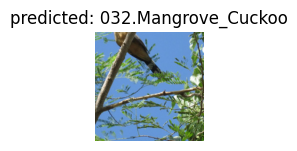

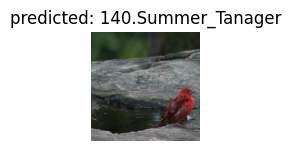

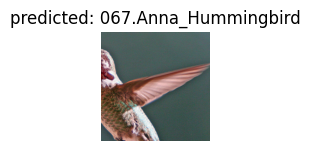

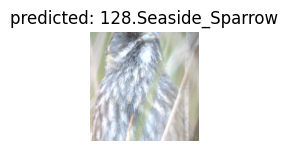

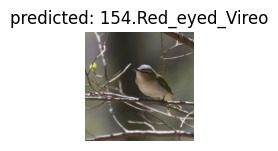

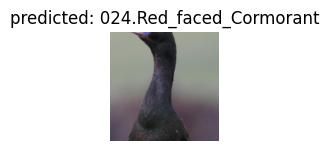

In [41]:
print(f"Grid search Feature extractor completed. Best metrics: {best_n_f_e_grid_metrics}")
print(f"Best parameters: {best_n_f_e_params}")

torch.save(best_n_f_e_grid_model.state_dict(), f"./results/best_model_f_e_{timestamp}.pth")

visualize_model(best_n_f_e_grid_model, num_images=6)
df = pd.DataFrame(table_data)
df.to_csv(f"./results/grid_search_results_new_feature_extractor_{timestamp}.csv", index=False)
itables.show(df, 
             lengthMenu=[5, 10, 20], 
             scrollX=True, 
             classes="display compact"
            )

#### 5.2. Finetuning

In [42]:
model_new_fine_tuning = torchvision.models.densenet121(pretrained=True)

In [43]:
for param in model_new_fine_tuning.parameters():
    param.requires_grad = False

for param in model_new_fine_tuning.features.denseblock4.denselayer16.parameters():
    param.requires_grad = True

# We reuse the classifier from the feature extractor as it has some good weigth initialization
model_new_fine_tuning.classifier = best_n_f_e_classifier

for param in model_new_fine_tuning.classifier.parameters():
    param.requires_grad = True

print_model(model_new_fine_tuning)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [44]:
model_new_fine_tuning = model_new_fine_tuning.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_new_fine_tuning = optim.SGD([p for p in model_new_fine_tuning.parameters() if p.requires_grad], lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
scheduler_new_fine_tuning = lr_scheduler.StepLR(optimizer_new_fine_tuning, step_size=7, gamma=0.1)

In [45]:
model_new_fine_tuning, _, _ = run_training(
    model_new_fine_tuning,
    criterion,
    optimizer_new_fine_tuning,
    scheduler_new_fine_tuning,
    {'train': train_dataloaders, 'val': val_dataloaders},
    {'train': len(x_train), 'val': len(x_val)},
    device,
    num_epochs=50
)

Epoch 1/50
----------
Train Loss: 0.1899 Acc: 0.9812
Val Loss: 2.5053 Acc: 0.4356
Epoch 2/50
----------
Train Loss: 0.1871 Acc: 0.9796
Val Loss: 2.4971 Acc: 0.4422
Epoch 3/50
----------
Train Loss: 0.1791 Acc: 0.9824
Val Loss: 2.4912 Acc: 0.4422
Epoch 4/50
----------
Train Loss: 0.1667 Acc: 0.9867
Val Loss: 2.4851 Acc: 0.4533
Epoch 5/50
----------
Train Loss: 0.1745 Acc: 0.9855
Val Loss: 2.5137 Acc: 0.4400
Epoch 6/50
----------
Train Loss: 0.1683 Acc: 0.9824
Val Loss: 2.4807 Acc: 0.4511
Epoch 7/50
----------
Train Loss: 0.1604 Acc: 0.9843
Val Loss: 2.5010 Acc: 0.4444
Epoch 8/50
----------
Train Loss: 0.1621 Acc: 0.9855
Val Loss: 2.4891 Acc: 0.4489
Epoch 9/50
----------
Train Loss: 0.1589 Acc: 0.9894
Val Loss: 2.5131 Acc: 0.4378
Epoch 10/50
----------
Train Loss: 0.1546 Acc: 0.9875
Val Loss: 2.4727 Acc: 0.4533
Early stopping
Training complete in 0m 34s
Best val Acc: 0.453333


In [46]:

output_buffer = StringIO()
original_stdout = sys.stdout
sys.stdout = tee_stdout = type('TeeStdout', (), {
    'write': lambda self, x: (output_buffer.write(x), original_stdout.write(x)),
    'flush': lambda self: (output_buffer.flush(), original_stdout.flush())
})()

timestamp = int(time.time())
try:
    param_grid = {
        'learning_rate': [0.01, 0.001,0.0001, 0.1],
        'weight_decay': [0, 0.0001,  0.001],                 
    }
    
    tried_combinations_file = f"./results/tried_n_f_t_combinations.json"
    tried_combinations = []

    if os.path.exists(tried_combinations_file):
        with open(tried_combinations_file, 'r') as f:
            tried_combinations = json.load(f)


    grid = list(ParameterGrid(param_grid))
    print(f"Total Fine tunning combinations: {len(grid)}")


    table_data = []
    best_n_f_t_grid_model = None
    best_n_f_t_grid_metrics = { 'best_val_acc': 0, 'best_train_acc': 0, 'best_epoch': 0, 'best_val_loss': 0, 'best_train_loss': 0 }
    best_n_f_t_params = None
    criterion = nn.CrossEntropyLoss()
    def param_to_str(params):
        return json.dumps(params, sort_keys=True)

    for i, params in enumerate(grid):
        folder_name = f"f-t-{params['learning_rate']}-{params['weight_decay']}"
        model_n_f_t_grid = torchvision.models.densenet121(pretrained=True)

        for param in model_n_f_t_grid.parameters():
            param.requires_grad = False

        for param in model_n_f_t_grid.features.denseblock4.denselayer16.parameters():
            param.requires_grad = True

        # We reuse the classifier from the feature extractor as it has some good weigth initialization
        model_n_f_t_grid.classifier = best_n_f_e_classifier

        for param in model_n_f_t_grid.classifier.parameters():
            param.requires_grad = True


        model_n_f_t_grid = model_n_f_t_grid.to(device)
        params_str = param_to_str(params)
        if params_str in tried_combinations:
            print(f"Skipping already tried combination {i+1}/{len(grid)}: {params}")
            continue
        print(f"Trying combination {i+1}/{len(grid)}: {params}")
        try:

            optimizer_n_f_e_grid = optim.Adam(
                model_n_f_t_grid.classifier.parameters(),
                lr=params['learning_rate'],
                weight_decay=params['weight_decay'],
            )
            scheduler_n_f_t_grid = lr_scheduler.ReduceLROnPlateau(optimizer_n_f_e_grid)
            best_model_n_f_t_grid, metrics, time_elapsed = run_training(
                model_n_f_t_grid,
                criterion,
                optimizer_n_f_e_grid,
                scheduler_n_f_t_grid,
                {'train': train_dataloaders, 'val': val_dataloaders},
                {'train': len(x_train), 'val': len(x_val)},
                device,
                num_epochs=50,
                name=folder_name
            )

            table_data.append({
                'learning_rate': params['learning_rate'],
                'weight_decay': params['weight_decay'],
                'dropout_rate': best_model_n_f_t_grid.classifier[0].p,
                'val_accuracy': metrics['best_val_acc'],
                'train_accuracy': metrics['best_train_acc'],
                'val_loss': metrics['best_val_loss'],
                'train_loss': metrics['best_train_loss'],
                'epoch': metrics['best_epoch'],
                'time_elapsed': time_elapsed,
            })

            if metrics['best_val_acc'] > best_n_f_t_grid_metrics['best_val_acc']:
                best_n_f_t_params = params
                best_n_f_t_grid_model = best_model_n_f_t_grid
                best_n_f_t_grid_metrics = metrics
            
            tried_combinations.append(params_str)
            with open(tried_combinations_file, 'w') as f:
                json.dump(tried_combinations, f)

        except Exception as e:
            print(f"Error with params {params}", str(e))
finally:
    # Restore original stdout
    sys.stdout = original_stdout
    # Write captured output to file
    with open(f"./results/output-n-f-t-{timestamp}.txt", 'w') as file:
        file.write(output_buffer.getvalue())

Total Fine tunning combinations: 12
Trying combination 1/12: {'learning_rate': 0.01, 'weight_decay': 0}
Epoch 1/50
----------
Train Loss: 3.4730 Acc: 0.4427
Val Loss: 6.2090 Acc: 0.2733
Epoch 2/50
----------
Train Loss: 2.3777 Acc: 0.5733
Val Loss: 6.3401 Acc: 0.2733
Epoch 3/50
----------
Train Loss: 2.3469 Acc: 0.6141
Val Loss: 7.1151 Acc: 0.2911
Epoch 4/50
----------
Train Loss: 2.4058 Acc: 0.6200
Val Loss: 8.0657 Acc: 0.2667
Epoch 5/50
----------
Train Loss: 1.9973 Acc: 0.6616
Val Loss: 8.1368 Acc: 0.2778
Epoch 6/50
----------
Train Loss: 1.9919 Acc: 0.6765
Val Loss: 7.6212 Acc: 0.2911
Epoch 7/50
----------
Train Loss: 1.5361 Acc: 0.7333
Val Loss: 7.5931 Acc: 0.3156
Epoch 8/50
----------
Train Loss: 1.6043 Acc: 0.7302
Val Loss: 8.4961 Acc: 0.2756
Epoch 9/50
----------
Train Loss: 1.7478 Acc: 0.7310
Val Loss: 8.4996 Acc: 0.3111
Epoch 10/50
----------
Train Loss: 1.4681 Acc: 0.7616
Val Loss: 8.5306 Acc: 0.3489
Epoch 11/50
----------
Train Loss: 1.4112 Acc: 0.7725
Val Loss: 8.3810 Acc:

Grid search fine tunning completed. Best metrics: {'best_val_acc': 0.44666666666666666, 'best_train_acc': 0.9631372549019608, 'best_epoch': 4, 'best_val_loss': 3.0126853317684597, 'best_train_loss': 0.1343296079249943}
Best parameters: {'learning_rate': 0.0001, 'weight_decay': 0.001}


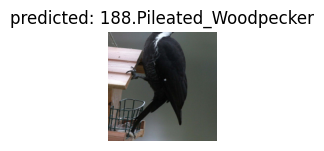

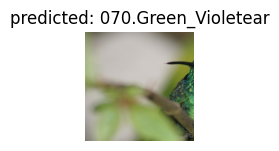

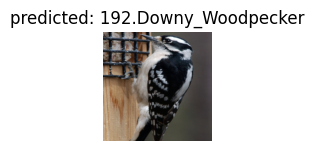

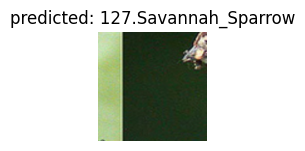

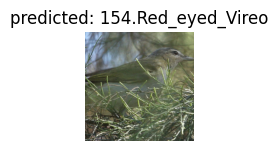

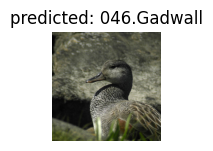

In [47]:

print(f"Grid search fine tunning completed. Best metrics: {best_n_f_t_grid_metrics}")
print(f"Best parameters: {best_n_f_t_params}")

torch.save(best_n_f_t_grid_model.state_dict(), f"./results/best_model_f_t_{timestamp}.pth")
visualize_model(best_n_f_t_grid_model, num_images=6)

df = pd.DataFrame(table_data)
df.to_csv(f"./results/grid_search_results_new_fine_tuning_{timestamp}.csv", index=False)
itables.show(df, 
             lengthMenu=[5, 10, 20], 
             scrollX=True, 
             classes="display compact"
            )

<font color=white>Answer: Here explain your experiments, compare and comment results. 

Draw some conclusions from this assignment.</font>

##### Experiments


<font color=white>Answer: Here explain your experiments, compare and comment results. 

Draw some conclusions from this assignment.</font>

## Experiments

For our experiments we started with a model ResNet-18 as the base model. It was pre-trained on ImageNet so we tried applying Feature extraction and Fine-tuning to see if we could make use of the already trained architecture. 

2.1. Feature Extraction: For feature extraction we mantained ResNet as the basemodel by freezing its layers and just trained the classifier. We did a gridsearch with the params:

     param_grid = {
        'learning_rate': [0.01, 0.001,0.0001, 0.1],
        'weight_decay': [0, 0.0001,  0.001],                 
        'dropout_rate': [0, 0.2, 0.5],
    }
    
Which results in 36 different models. This was done to look for the best hyperparameters.

2.2. Fine Tuning: We used the ResNet and unfreezed its final layer and reused the old classifier. The objective was to make use of the weights from the old classifier along with unfreezing the last layers. This was done with the ovjective to help the model re-learn its most specific features with our bird dataset. Afterwards we did a gridsearch with the params: 

     param_grid = {
        'learning_rate': [0.01, 0.001,0.0001, 0.1],
        'weight_decay': [0, 0.0001,  0.001],                 
        'dropout_rate': [0, 0.2, 0.5],
    }
    
Which results in 36 different models. This was done to look for the best hyperparameters.


The results we obtained seemed to say that we were overfitting, so we decided to change to DenseNet, which is known to alleviate vanishing gradients. We applied the same training strategies as before: 


5.1. Feature Extraction: For feature extraction we mantained ResNet as the basemodel by freezing its layers and just trained the classifier. We did a gridsearch with the params:

     param_grid = {
        'learning_rate': [0.01, 0.001,0.0001, 0.1],
        'weight_decay': [0, 0.0001,  0.001],                 
        'dropout_rate': [0, 0.2, 0.5],
    }
    
Which results in 36 different models. This was done to look for the best hyperparameters.

5.2. Fine Tuning: We used the ResNet and unfreezed its final layer and reused the old classifier. The objective was to make use of the weights from the old classifier along with unfreezing the last layers. This was done with the ovjective to help the model re-learn its most specific features with our bird dataset. Afterwards we did a gridsearch with the params: 

     param_grid = {
        'learning_rate': [0.01, 0.001,0.0001, 0.1],
        'weight_decay': [0, 0.0001,  0.001],                 
        'dropout_rate': [0, 0.2, 0.5],
    }

## Results

### 3.1. Resnet Feature Extraction


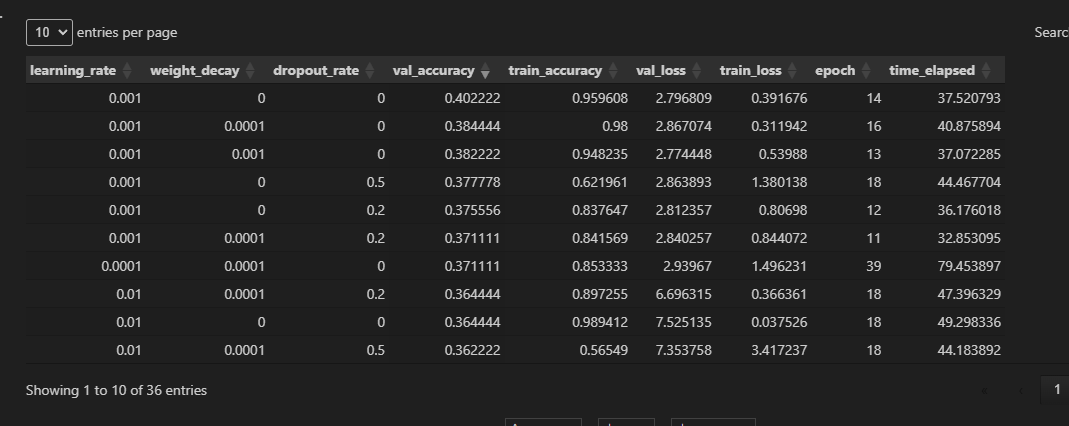

The hyperparameter tuning showed that the best validation accuracy (0.402222) is the one with a lr of 0.001 and no weight decay or dropout. The other configurations seem to show lower validation accuracy indicating a possible overfitting or underfitting, depending on the train accuracy. 

### 3.2. Resnet Fine Tuning



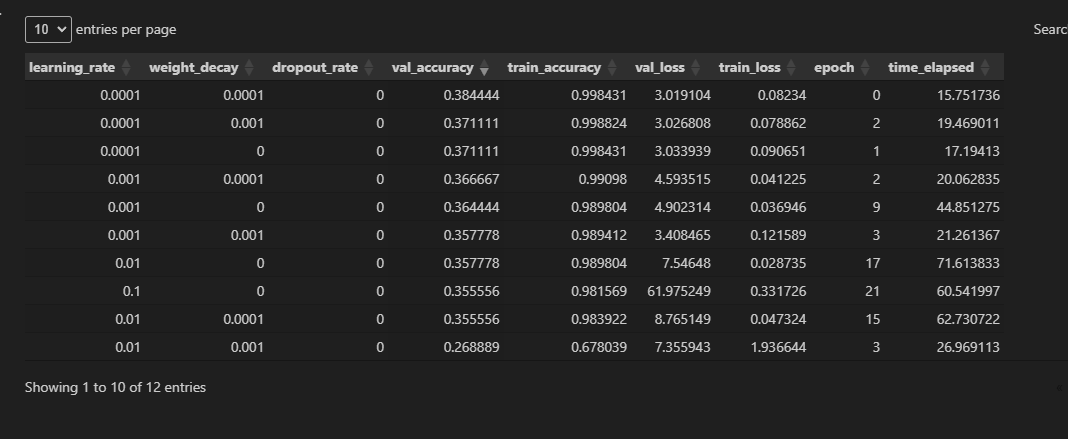

The hyperparameter tuning showed that the best validation accuracy (0.384444) is achieved with a learning rate of 0.0001 and both weight decay and dropout set to 0.0001 and 0. Other configurations returned lower validation accuracy, which looks like overfitting for the first 9 cases. It is also interesting to see that higher learning rates like 0.1 caused a drastic drop in validation performance (val_accuracy of 0.355556 with a high val_loss), indicating poor generalization. This might seem to say that smaller learning rates with minimal regularization seem to result in better results for this setup.

### 5.1. DenseNet Feature extraction

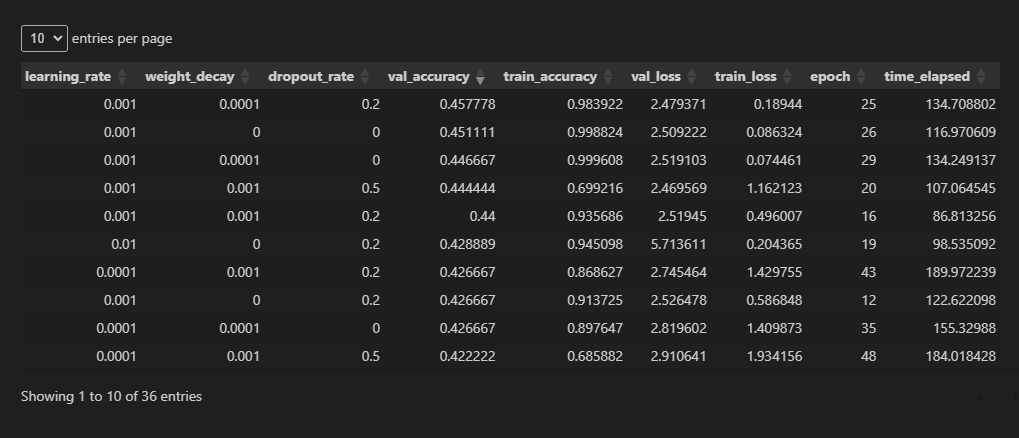

The hyperparameters for the DenseNet Feature Extraction setup showed that the best val_accuracy (0.457778) was achieved using a learning rate of 0.001, weight decay of 0.0001, and a dropout rate of 0.2. This configuration seemed to show an overall better balance between training and validation, surpassing all previous cases. Overall Desnsenet seems to work better than the ResNet.

### 5.2 DenseNet Fine tuning



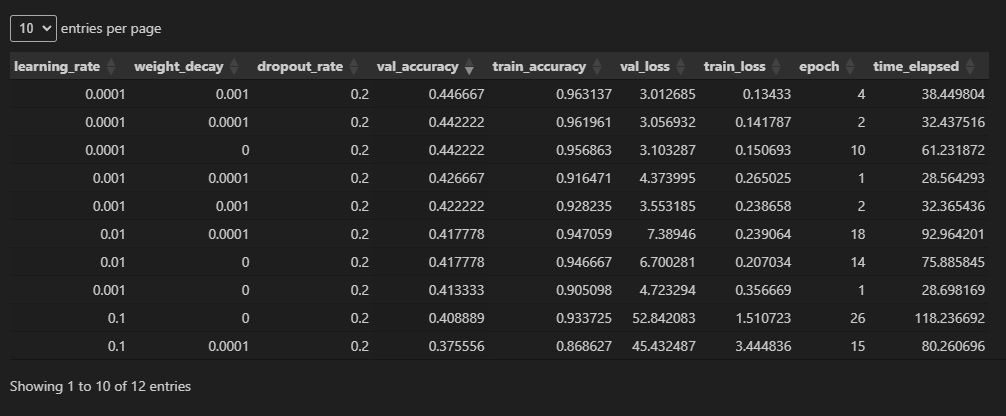

Finally, FineTuning didn't seem to surpass the feature extraction, we had the biggest val_accuracy of 0.446667 with few epochs. This might be because we used the classifier obtained from the feature extractor, which meant that the classifier has already been trained with good weights. 

## Conclusions

DenseNet seems to consistently outperform ResNet, this might be due to the fact that DenseNet solves the problem of vanishing gradients and works a bit better against overfitting. On the other hand, it is also deeper, which is why it might give better results. Our finetuning does not seem to work better than feature extraction in general, probably because our training is too simple in comparison to the already trained model. As conclusion, we believe that there is overfitting in most models, hinting that we could benefit from a larger training set, increasing training. It also showed that deeper networks work better because they get to learn more features. 